# 💧 Modèle prédictif de consommation d'eau urbaine

**Objectif** : prédire les débits d'eau sur des Postes de Relevage (PR) à partir d'un historique 5 minutes sur 2 ans, et **comprendre les facteurs d'influence**.

## Plan du notebook

1. **Préparation** : chargement / génération des données
2. **Exploration** : visualiser les patterns (journée, semaine, année)
3. **Feature engineering** : créer des variables prédictives à partir de la date
4. **Modèle baseline** : moyennes historiques (point de comparaison)
5. **Modèle ML** : LightGBM avec features temporelles
6. **Évaluation** : mesurer la qualité des prédictions
7. **Interprétation** : quels facteurs comptent le plus ?
8. **Prédiction long terme** : étendre aux horizons longs

## Conseils d'utilisation

- Exécutez les cellules dans l'ordre (Shift+Entrée)
- Les sections marquées 🔧 sont à adapter à vos vraies données
- Les sections marquées 💡 contiennent des explications pédagogiques

## 0. Installation des bibliothèques

À exécuter une seule fois. Si vous êtes sur Anaconda, la plupart sont déjà installées.

In [1]:
# Décommentez la ligne suivante si vous avez besoin d'installer
# !pip install pandas numpy matplotlib seaborn scikit-learn lightgbm holidays

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('✅ Bibliothèques chargées')

✅ Bibliothèques chargées


## 1. Chargement des données

### 🔧 Option A : charger vos vraies données

Décommentez et adaptez selon votre format. Le DataFrame final doit contenir :
- une colonne `datetime` (index temporel)
- une colonne `pr` (identifiant du poste de relevage)
- une colonne `debit` (la valeur mesurée, en m³/h par exemple)

In [3]:
# Exemple si vos données sont en CSV :
# df = pd.read_csv('mes_donnees.csv', parse_dates=['datetime'])

# Exemple si chaque PR est dans un fichier séparé :
# dfs = []
# for fichier, nom_pr in [('pr1.csv', 'PR_NORD'), ('pr2.csv', 'PR_SUD')]:
#     d = pd.read_csv(fichier, parse_dates=['datetime'])
#     d['pr'] = nom_pr
#     dfs.append(d)
# df = pd.concat(dfs, ignore_index=True)

### Option B : générer des données simulées réalistes

On simule 2 ans de données pour 3 PR avec tous les patterns réalistes du monde de l'eau :
- pics matin et soir
- weekend ≠ semaine
- saisonnalité été/hiver
- effet météo (température)
- bruit aléatoire
- quelques valeurs manquantes (comme en vrai)

👉 **Utilisez cette section pour vous familiariser**, puis remplacez par vos vraies données.

In [4]:
def generer_donnees_simulees(date_debut='2023-01-01', date_fin='2024-12-31', 
                              liste_pr=None, seed=42):
    """Génère des données simulées réalistes de débit sur des PR."""
    if liste_pr is None:
        liste_pr = {
            'PR_CENTRE': {'base': 80, 'amplitude': 50},   # zone urbaine dense
            'PR_RESIDENTIEL': {'base': 40, 'amplitude': 30},  # quartier résidentiel
            'PR_INDUSTRIEL': {'base': 60, 'amplitude': 20},  # zone industrielle (moins de variabilité)
        }
    
    rng = np.random.default_rng(seed)
    dates = pd.date_range(date_debut, date_fin, freq='5min')
    dfs = []
    
    for nom_pr, params in liste_pr.items():
        h = np.asarray(dates.hour + dates.minute / 60)
        jour_sem = np.asarray(dates.dayofweek)  # 0=lundi, 6=dimanche
        jour_an = np.asarray(dates.dayofyear)
        
        # Profil journalier (deux pics : matin et soir)
        pic_matin = np.exp(-((h - 7.5) ** 2) / 4)
        pic_soir = np.exp(-((h - 19) ** 2) / 5)
        profil_jour = pic_matin + 0.9 * pic_soir
        
        # Effet weekend (décalage des pics, légèrement moins consommé)
        est_weekend = (jour_sem >= 5).astype(float)
        pic_we = np.exp(-((h - 10) ** 2) / 8)
        profil_jour = profil_jour * (1 - 0.4 * est_weekend) + 0.6 * pic_we * est_weekend
        
        # Saisonnalité annuelle (été = plus de consommation, arrosage)
        saison = 0.3 * np.sin(2 * np.pi * (jour_an - 80) / 365)
        
        # Spécificité PR industriel : profil aplati en semaine, presque zéro le weekend
        if nom_pr == 'PR_INDUSTRIEL':
            profil_jour = ((h > 6) & (h < 22)).astype(float) * (1 - est_weekend * 0.85)
        
        # Construction du signal
        debit = params['base'] + params['amplitude'] * profil_jour + 10 * saison
        debit *= (1 + 0.05 * rng.standard_normal(len(dates)))  # bruit multiplicatif
        debit = np.maximum(debit, 5)  # pas de débit négatif
        
        # Quelques valeurs manquantes aléatoires (1%)
        masque_nan = rng.random(len(dates)) < 0.01
        debit[masque_nan] = np.nan
        
        d = pd.DataFrame({'datetime': dates, 'pr': nom_pr, 'debit': debit})
        dfs.append(d)
    
    return pd.concat(dfs, ignore_index=True)

df = generer_donnees_simulees()
print(f'Shape : {df.shape}')
print(f'Période : {df["datetime"].min()} → {df["datetime"].max()}')
print(f'PR : {df["pr"].unique().tolist()}')
df.head()

Shape : (630723, 3)
Période : 2023-01-01 00:00:00 → 2024-12-31 00:00:00
PR : ['PR_CENTRE', 'PR_RESIDENTIEL', 'PR_INDUSTRIEL']


,datetime,pr,debit
0,2023-01-01 00:00:00,PR_CENTRE,78.240766
1,2023-01-01 00:05:00,PR_CENTRE,73.059221
2,2023-01-01 00:10:00,PR_CENTRE,79.958406
3,2023-01-01 00:15:00,PR_CENTRE,80.691033
4,2023-01-01 00:20:00,PR_CENTRE,69.548787


## 2. Exploration des données

Avant tout modèle, **toujours regarder ses données**. C'est la phase la plus importante et souvent négligée.

In [5]:
# Vue d'ensemble par PR
df.groupby('pr')['debit'].describe()

,count,mean,std,min,25%,50%,75%,max
pr,,,,,,,,
PR_CENTRE,208152.0,94.894654,16.917840,60.479528,81.493503,88.914459,107.245824,153.687433
PR_INDUSTRIEL,208213.0,70.048611,10.369641,45.536302,60.716145,67.702369,79.652619,98.656435
PR_RESIDENTIEL,208152.0,48.937130,10.196720,30.167804,40.871068,45.452272,56.415608,83.949161


In [6]:
# Valeurs manquantes
print('Valeurs manquantes par PR :')
print(df.groupby('pr')['debit'].apply(lambda s: s.isna().sum()))

Valeurs manquantes par PR :
pr
PR_CENTRE         2089
PR_INDUSTRIEL     2028
PR_RESIDENTIEL    2089
Name: debit, dtype: int64


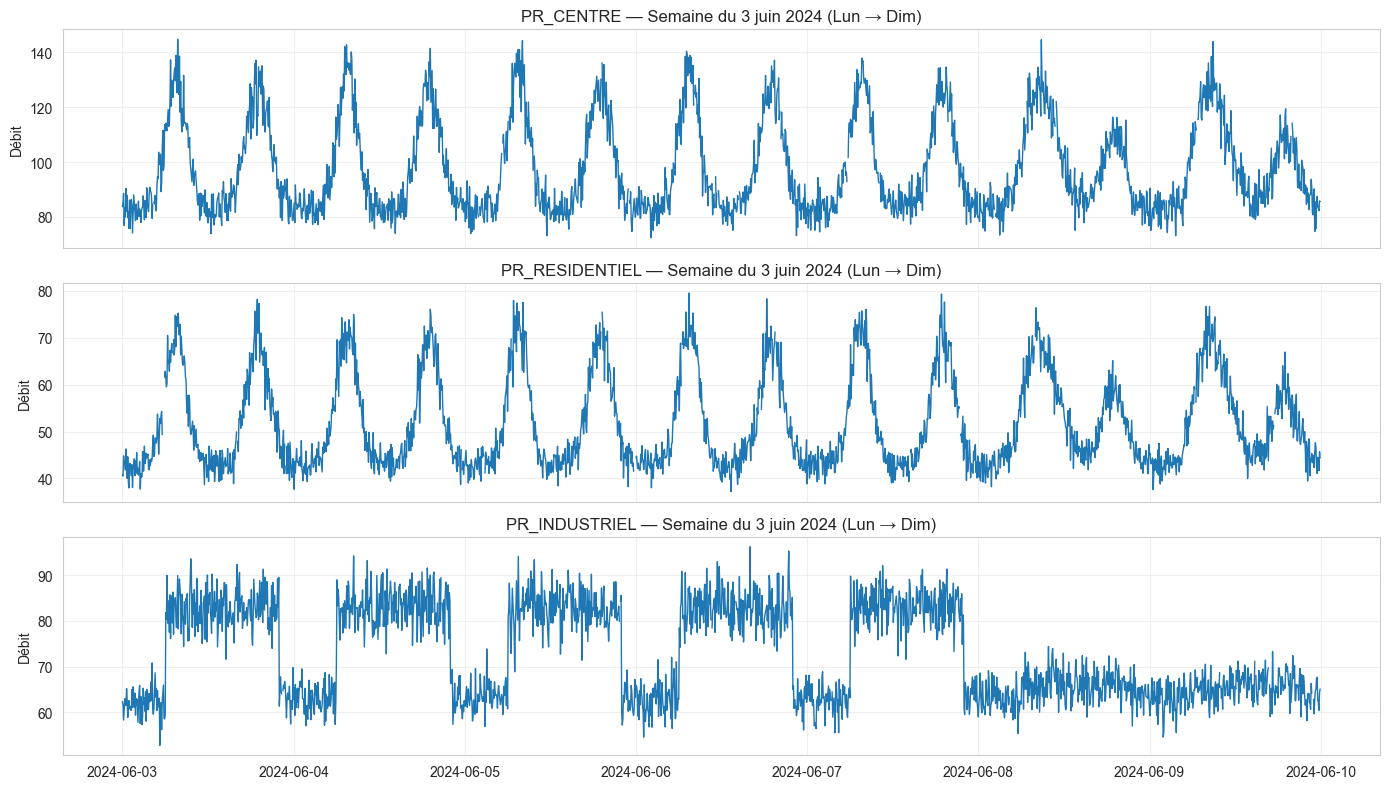

In [7]:
# Visualisation : une semaine type pour chaque PR
fig, axes = plt.subplots(len(df['pr'].unique()), 1, figsize=(14, 8), sharex=True)
if len(df['pr'].unique()) == 1:
    axes = [axes]

for ax, pr in zip(axes, df['pr'].unique()):
    d = df[(df['pr'] == pr) & (df['datetime'] >= '2024-06-03') & (df['datetime'] < '2024-06-10')]
    ax.plot(d['datetime'], d['debit'], linewidth=1)
    ax.set_title(f'{pr} — Semaine du 3 juin 2024 (Lun → Dim)')
    ax.set_ylabel('Débit')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

💡 **Lecture** : on voit clairement les pics matin/soir, le creux de nuit, et la différence semaine/weekend. Le PR industriel a un comportement très différent.

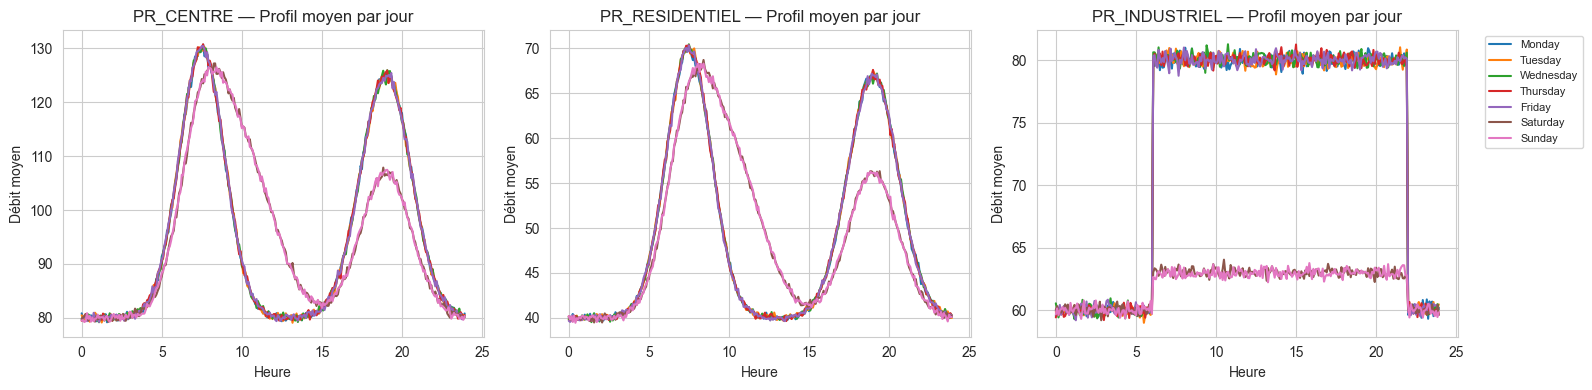

In [8]:
# Profil journalier moyen par jour de la semaine
df_viz = df.copy()
df_viz['heure'] = df_viz['datetime'].dt.hour + df_viz['datetime'].dt.minute / 60
df_viz['jour_sem'] = df_viz['datetime'].dt.day_name()

ordre_jours = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, len(df['pr'].unique()), figsize=(16, 4), sharey=False)
if len(df['pr'].unique()) == 1:
    axes = [axes]

for ax, pr in zip(axes, df['pr'].unique()):
    d = df_viz[df_viz['pr'] == pr]
    pivot = d.groupby(['heure', 'jour_sem'])['debit'].mean().unstack()[ordre_jours]
    pivot.plot(ax=ax, legend=(ax == axes[-1]))
    ax.set_title(f'{pr} — Profil moyen par jour')
    ax.set_xlabel('Heure')
    ax.set_ylabel('Débit moyen')

if len(axes) > 1:
    axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

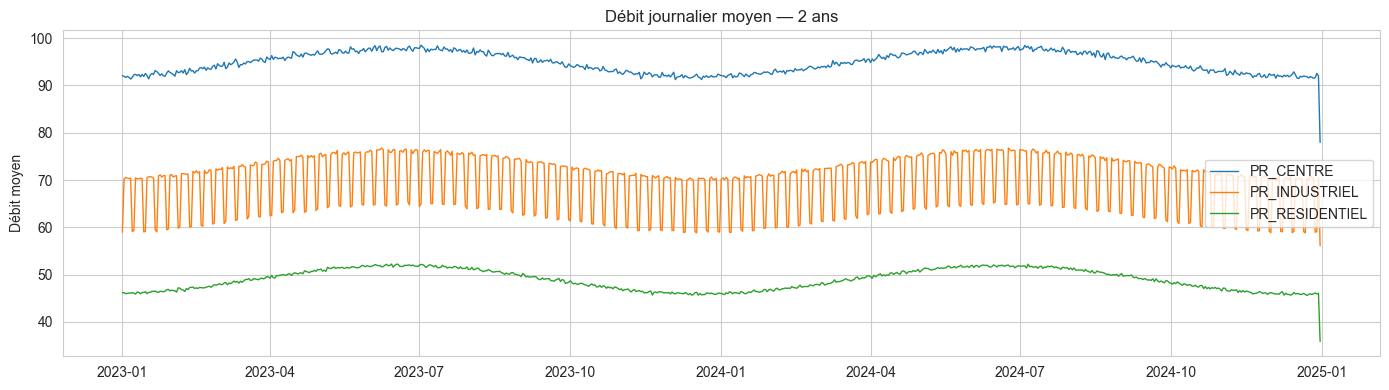

In [9]:
# Tendance annuelle (moyenne journalière)
df_jour = df.set_index('datetime').groupby('pr')['debit'].resample('D').mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
for pr in df_jour['pr'].unique():
    d = df_jour[df_jour['pr'] == pr]
    ax.plot(d['datetime'], d['debit'], label=pr, linewidth=1)
ax.set_title('Débit journalier moyen — 2 ans')
ax.legend()
ax.set_ylabel('Débit moyen')
plt.tight_layout()
plt.show()

## 3. Feature engineering

💡 **Principe clé** : un modèle ML ne comprend pas qu'une date est "un dimanche d'été". Il faut le lui dire explicitement en créant des **variables (features)** à partir du datetime.

On va créer :
- **Features calendaires** : heure, jour de la semaine, mois, jour de l'année
- **Features cycliques** : sin/cos pour que le modèle comprenne que 23h est proche de 0h
- **Features binaires** : weekend, jour férié, période de vacances
- **Features de lag** : valeur il y a 5 min, 1h, 24h, 7 jours
- **Features de rolling** : moyenne sur la dernière heure, écart-type, etc.

In [10]:
import holidays

feries_fr = holidays.France(years=range(2022, 2027))

def creer_features_calendaires(df, col_date='datetime'):
    """Ajoute les features dérivées de la date (sans connaître le passé)."""
    df = df.copy()
    dt = df[col_date]
    
    # Features basiques
    df['heure'] = dt.dt.hour
    df['minute'] = dt.dt.minute
    df['jour_semaine'] = dt.dt.dayofweek
    df['jour_mois'] = dt.dt.day
    df['jour_annee'] = dt.dt.dayofyear
    df['mois'] = dt.dt.month
    df['trimestre'] = dt.dt.quarter
    df['annee'] = dt.dt.year
    df['semaine_annee'] = dt.dt.isocalendar().week.astype(int)
    
    # Features binaires
    df['est_weekend'] = (df['jour_semaine'] >= 5).astype(int)
    df['est_ferie'] = dt.dt.date.astype('object').map(lambda d: d in feries_fr).astype(int)
    df['est_lundi'] = (df['jour_semaine'] == 0).astype(int)
    df['est_vendredi'] = (df['jour_semaine'] == 4).astype(int)
    
    # Vacances scolaires (approximation : juillet-août pour les vacances d'été)
    df['est_vacances_ete'] = ((df['mois'] == 7) | (df['mois'] == 8)).astype(int)
    
    # Features cycliques (sin/cos) pour que le modèle comprenne la continuité
    # Très important pour les variables comme l'heure ou le mois
    df['heure_sin'] = np.sin(2 * np.pi * (df['heure'] + df['minute']/60) / 24)
    df['heure_cos'] = np.cos(2 * np.pi * (df['heure'] + df['minute']/60) / 24)
    df['jour_sem_sin'] = np.sin(2 * np.pi * df['jour_semaine'] / 7)
    df['jour_sem_cos'] = np.cos(2 * np.pi * df['jour_semaine'] / 7)
    df['mois_sin'] = np.sin(2 * np.pi * df['mois'] / 12)
    df['mois_cos'] = np.cos(2 * np.pi * df['mois'] / 12)
    df['jour_annee_sin'] = np.sin(2 * np.pi * df['jour_annee'] / 365)
    df['jour_annee_cos'] = np.cos(2 * np.pi * df['jour_annee'] / 365)
    
    return df

df_feat = creer_features_calendaires(df)
print(f'Nombre de features calendaires créées : {df_feat.shape[1] - df.shape[1]}')
df_feat.head(2)

Nombre de features calendaires créées : 22


,datetime,pr,debit,heure,minute,jour_semaine,jour_mois,jour_annee,mois,trimestre,...,est_vendredi,est_vacances_ete,heure_sin,heure_cos,jour_sem_sin,jour_sem_cos,mois_sin,mois_cos,jour_annee_sin,jour_annee_cos
0,2023-01-01 00:00:00,PR_CENTRE,78.240766,0,0,6,1,1,1,1,...,0,0,0.000000,1.000000,-0.781831,0.62349,0.5,0.866025,0.017213,0.999852
1,2023-01-01 00:05:00,PR_CENTRE,73.059221,0,5,6,1,1,1,1,...,0,0,0.021815,0.999762,-0.781831,0.62349,0.5,0.866025,0.017213,0.999852


In [11]:
def creer_features_lag(df, col_cible='debit', col_groupe='pr', lags=None, rolling_windows=None):
    """
    Ajoute des features de décalage temporel (lag) et de moyennes mobiles.
    
    ⚠️ ATTENTION : ces features utilisent le passé. Elles ne sont disponibles
    qu'au moment de la prédiction si on connaît l'historique récent.
    Très utiles pour la prédiction court terme, moins pour le long terme.
    """
    if lags is None:
        # 5min, 15min, 1h, 6h, 24h, 7j (en nombre de pas de 5 min)
        lags = [1, 3, 12, 72, 288, 2016]
    if rolling_windows is None:
        rolling_windows = [12, 288]  # 1h, 24h
    
    df = df.sort_values([col_groupe, 'datetime']).copy()
    
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby(col_groupe)[col_cible].shift(lag)
    
    for w in rolling_windows:
        # On décale d'un pas pour ne pas inclure la valeur courante (anti-fuite de données)
        roll = df.groupby(col_groupe)[col_cible].shift(1).rolling(w, min_periods=1)
        df[f'roll_mean_{w}'] = roll.mean().reset_index(level=0, drop=True)
        df[f'roll_std_{w}'] = roll.std().reset_index(level=0, drop=True)
    
    return df

df_feat = creer_features_lag(df_feat)
print(f'Shape final : {df_feat.shape}')
df_feat.tail(2)

Shape final : (630723, 35)


,datetime,pr,debit,heure,minute,jour_semaine,jour_mois,jour_annee,mois,trimestre,...,lag_1,lag_3,lag_12,lag_72,lag_288,lag_2016,roll_mean_12,roll_std_12,roll_mean_288,roll_std_288
420480,2024-12-30 23:55:00,PR_RESIDENTIEL,36.894758,23,55,0,30,365,12,4,...,38.419579,37.172606,40.941633,56.192476,37.265036,40.484110,58.076412,2.723496,70.299338,10.009625
420481,2024-12-31 00:00:00,PR_RESIDENTIEL,35.875705,0,0,1,31,366,12,4,...,36.894758,40.072245,37.338293,60.880449,35.561461,33.972436,58.078992,2.723529,70.310799,9.993745


## 4. Split train / test

💡 **Règle d'or pour les séries temporelles** : **JAMAIS** de split aléatoire ! On respecte la chronologie : on entraîne sur le passé, on teste sur le futur. Sinon on triche (data leakage).

In [12]:
# On garde les 3 derniers mois pour le test
date_split = df_feat['datetime'].max() - pd.Timedelta(days=90)

train = df_feat[df_feat['datetime'] < date_split].copy()
test = df_feat[df_feat['datetime'] >= date_split].copy()

# Nettoyage : on enlève les lignes où la cible ou les lags sont manquants
train = train.dropna(subset=['debit'])
test = test.dropna(subset=['debit'])

print(f'Train : {len(train):,} lignes  ({train["datetime"].min()} → {train["datetime"].max()})')
print(f'Test  : {len(test):,} lignes  ({test["datetime"].min()} → {test["datetime"].max()})')

Train : 547,510 lignes  (2023-01-01 00:00:00 → 2024-10-01 23:55:00)
Test  : 77,007 lignes  (2024-10-02 00:00:00 → 2024-12-31 00:00:00)


## 5. Modèle baseline

💡 **Avant tout modèle complexe**, on construit un **modèle naïf** comme référence. Si notre modèle ML ne fait pas mieux que la moyenne historique, il ne sert à rien.

Baseline : pour chaque (PR, jour de la semaine, heure, minute), on prédit la moyenne historique observée dans le train.

In [13]:
# Construction du dictionnaire de moyennes
baseline = train.groupby(['pr', 'jour_semaine', 'heure', 'minute'])['debit'].mean().reset_index()
baseline.columns = ['pr', 'jour_semaine', 'heure', 'minute', 'pred_baseline']

test_eval = test.merge(baseline, on=['pr', 'jour_semaine', 'heure', 'minute'], how='left')
print('Baseline construite. Aperçu :')
test_eval[['datetime', 'pr', 'debit', 'pred_baseline']].head()

Baseline construite. Aperçu :


,datetime,pr,debit,pred_baseline
0,2024-10-02 00:00:00,PR_CENTRE,84.088776,80.137090
1,2024-10-02 00:05:00,PR_CENTRE,79.790296,80.509896
2,2024-10-02 00:10:00,PR_CENTRE,78.576156,80.587784
3,2024-10-02 00:15:00,PR_CENTRE,74.306527,80.613551
4,2024-10-02 00:20:00,PR_CENTRE,74.976656,80.097455


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluer(y_vrai, y_pred, nom='Modèle'):
    """Calcule MAE, RMSE et MAPE."""
    mae = mean_absolute_error(y_vrai, y_pred)
    rmse = np.sqrt(mean_squared_error(y_vrai, y_pred))
    mape = np.mean(np.abs((y_vrai - y_pred) / y_vrai)) * 100
    print(f'{nom:25s}  MAE = {mae:6.2f}   RMSE = {rmse:6.2f}   MAPE = {mape:5.2f}%')
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

perf_baseline = evaluer(test_eval['debit'], test_eval['pred_baseline'], 'Baseline (moyennes)')

Baseline (moyennes)        MAE =   3.61   RMSE =   4.52   MAPE =  5.68%


## 6. Modèle LightGBM

On utilise **LightGBM**, un algorithme de gradient boosting très efficace pour les données tabulaires. C'est souvent le meilleur compromis vitesse/performance pour ce type de problème.

In [15]:
import lightgbm as lgb

# Encodage du PR (variable catégorielle)
from sklearn.preprocessing import LabelEncoder
le_pr = LabelEncoder()
train['pr_id'] = le_pr.fit_transform(train['pr'])
test['pr_id'] = le_pr.transform(test['pr'])

# Liste des features à utiliser
features = [c for c in train.columns if c not in ['datetime', 'pr', 'debit']]
print(f'Nombre de features : {len(features)}')
print(features)

Nombre de features : 33
['heure', 'minute', 'jour_semaine', 'jour_mois', 'jour_annee', 'mois', 'trimestre', 'annee', 'semaine_annee', 'est_weekend', 'est_ferie', 'est_lundi', 'est_vendredi', 'est_vacances_ete', 'heure_sin', 'heure_cos', 'jour_sem_sin', 'jour_sem_cos', 'mois_sin', 'mois_cos', 'jour_annee_sin', 'jour_annee_cos', 'lag_1', 'lag_3', 'lag_12', 'lag_72', 'lag_288', 'lag_2016', 'roll_mean_12', 'roll_std_12', 'roll_mean_288', 'roll_std_288', 'pr_id']


In [16]:
X_train, y_train = train[features], train['debit']
X_test, y_test = test[features], test['debit']

modele = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

modele.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)],
    categorical_feature=['pr_id'],
)

Training until validation scores don't improve for 30 rounds


[50]	valid_0's l2: 17.7192


[100]	valid_0's l2: 14.2232


[150]	valid_0's l2: 14.0276


[200]	valid_0's l2: 13.9361


[250]	valid_0's l2: 13.8637


[300]	valid_0's l2: 13.8181


[350]	valid_0's l2: 13.7695


[400]	valid_0's l2: 13.742


[450]	valid_0's l2: 13.7216


[500]	valid_0's l2: 13.6976
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 13.6976


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [17]:
# Prédictions
test['pred_lgbm'] = modele.predict(X_test)

print('Comparaison des modèles :')
evaluer(test_eval['debit'], test_eval['pred_baseline'], 'Baseline (moyennes)')
perf_lgbm = evaluer(test['debit'], test['pred_lgbm'], 'LightGBM')

Comparaison des modèles :
Baseline (moyennes)        MAE =   3.61   RMSE =   4.52   MAPE =  5.68%
LightGBM                   MAE =   2.81   RMSE =   3.70   MAPE =  4.12%


💡 **Lecture des métriques** :
- **MAE** (erreur absolue moyenne) : en moyenne, on se trompe de X unités. Facile à interpréter.
- **RMSE** : pénalise plus fortement les grosses erreurs.
- **MAPE** : erreur en %. Permet de comparer entre PR de tailles différentes.

## 7. Visualisation des prédictions

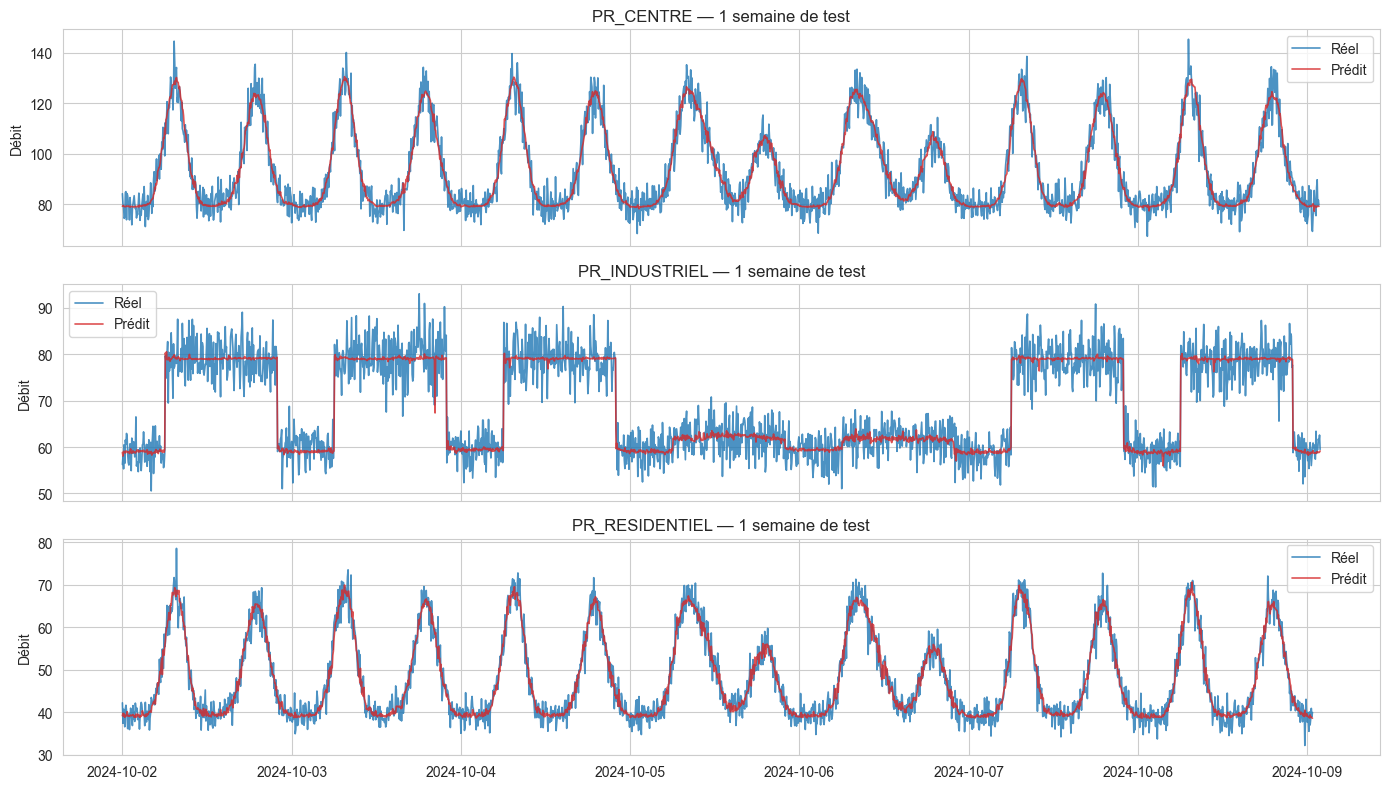

In [18]:
# Sur une semaine de test
fig, axes = plt.subplots(len(test['pr'].unique()), 1, figsize=(14, 8), sharex=True)
if len(test['pr'].unique()) == 1:
    axes = [axes]

for ax, pr in zip(axes, test['pr'].unique()):
    d = test[(test['pr'] == pr)].sort_values('datetime').head(7 * 288)  # 1 semaine
    ax.plot(d['datetime'], d['debit'], label='Réel', linewidth=1.2, alpha=0.8)
    ax.plot(d['datetime'], d['pred_lgbm'], label='Prédit', linewidth=1.2, alpha=0.8, color='C3')
    ax.set_title(f'{pr} — 1 semaine de test')
    ax.legend()
    ax.set_ylabel('Débit')

plt.tight_layout()
plt.show()

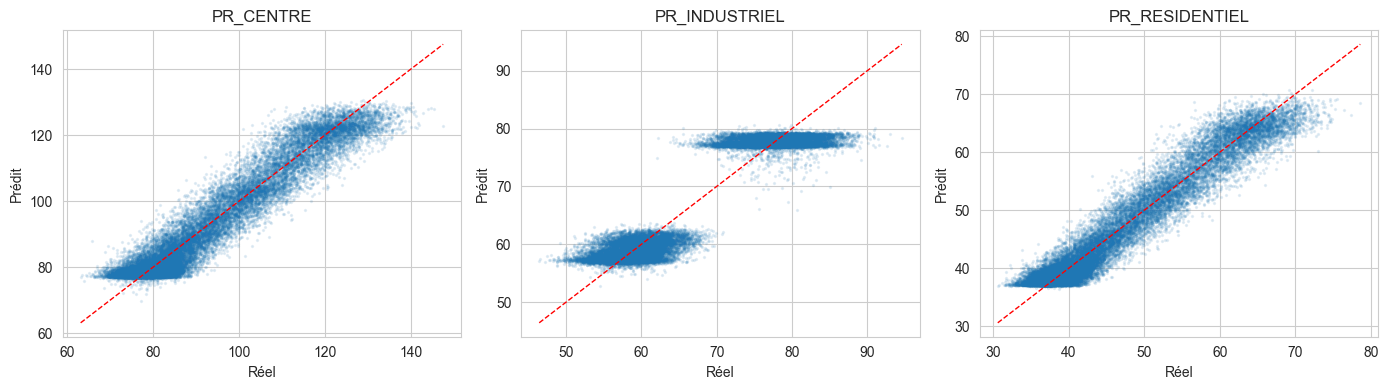

In [19]:
# Scatter prédit vs réel
fig, axes = plt.subplots(1, len(test['pr'].unique()), figsize=(14, 4))
if len(test['pr'].unique()) == 1:
    axes = [axes]

for ax, pr in zip(axes, test['pr'].unique()):
    d = test[test['pr'] == pr]
    ax.scatter(d['debit'], d['pred_lgbm'], alpha=0.1, s=2)
    lims = [d['debit'].min(), d['debit'].max()]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Réel')
    ax.set_ylabel('Prédit')
    ax.set_title(pr)

plt.tight_layout()
plt.show()

## 8. Interprétation : quels facteurs comptent le plus ?

C'est l'un de vos objectifs : **comprendre les facteurs d'influence**.

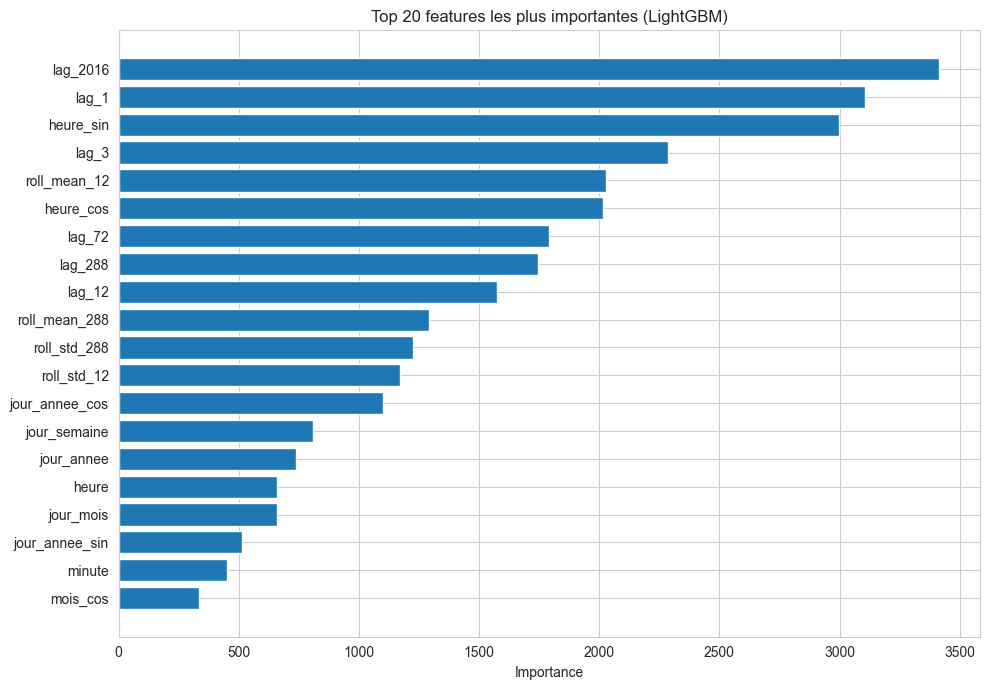

In [20]:
importances = pd.DataFrame({
    'feature': features,
    'importance': modele.feature_importances_,
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importances['feature'], importances['importance'])
ax.set_title('Top 20 features les plus importantes (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

💡 **Limite de l'importance LightGBM** : elle indique quelles features le modèle utilise, mais pas dans quel sens. Pour aller plus loin, on peut utiliser **SHAP** (analyse plus fine de l'effet de chaque variable).

Pour une première interprétation, **regardons les profils moyens par groupe**.

In [21]:
# Optionnel : analyse SHAP (décommentez si vous l'avez installé : pip install shap)
# import shap
# explainer = shap.TreeExplainer(modele)
# sample = X_test.sample(2000, random_state=0)
# shap_values = explainer.shap_values(sample)
# shap.summary_plot(shap_values, sample, max_display=15)

## 9. Prédiction long terme

⚠️ **Subtilité importante** : notre modèle utilise des features de lag (valeur il y a 1h, 24h, etc.). Pour prédire à 1h, on a besoin de la vraie valeur d'il y a 24h — OK.

Mais pour prédire à **6 mois**, on n'a pas ces valeurs. Deux stratégies :

1. **Modèle sans lag** : on entraîne un modèle qui n'utilise QUE les features calendaires (heure, jour, mois, férié...). Performance un peu moindre, mais utilisable à n'importe quel horizon.
2. **Récursif** : on prédit pas à pas et on utilise nos propres prédictions comme lags. Risque d'accumulation d'erreurs.

Pour le long terme, l'**option 1 est généralement préférable**.

In [22]:
# Modèle dédié long terme : que des features calendaires
features_long = [c for c in features if not c.startswith('lag_') and not c.startswith('roll_')]
print(f'Features long terme : {len(features_long)}')

modele_long = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    min_child_samples=50, random_state=42, n_jobs=-1, verbose=-1,
)

modele_long.fit(
    train[features_long], train['debit'],
    eval_set=[(test[features_long], test['debit'])],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)],
    categorical_feature=['pr_id'],
)

test['pred_long'] = modele_long.predict(test[features_long])
evaluer(test['debit'], test['pred_long'], 'LightGBM long terme')

Features long terme : 23


Training until validation scores don't improve for 30 rounds


Early stopping, best iteration is:
[307]	valid_0's l2: 13.0837
LightGBM long terme        MAE =   2.74   RMSE =   3.62   MAPE =  4.01%


{'mae': 2.744793387232309,
 'rmse': 3.617145647211309,
 'mape': 4.010142269529368}

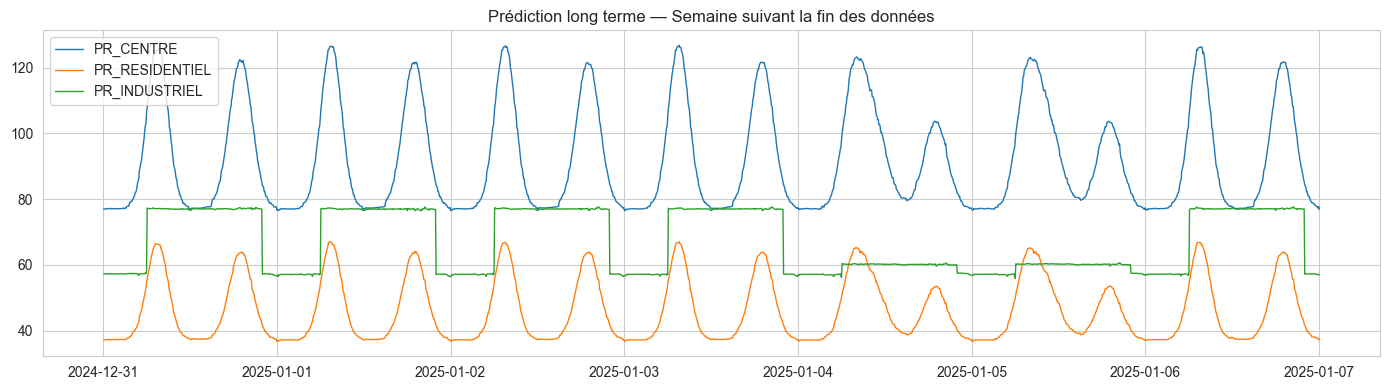

In [23]:
# Exemple : prédiction sur les 30 prochains jours après la fin des données
date_max = df_feat['datetime'].max()
dates_futur = pd.date_range(date_max + pd.Timedelta(minutes=5), periods=30 * 288, freq='5min')

futurs = []
for pr in df['pr'].unique():
    f = pd.DataFrame({'datetime': dates_futur, 'pr': pr})
    futurs.append(f)
futur = pd.concat(futurs, ignore_index=True)

futur = creer_features_calendaires(futur)
futur['pr_id'] = le_pr.transform(futur['pr'])
futur['pred'] = modele_long.predict(futur[features_long])

# Visualisation
fig, ax = plt.subplots(figsize=(14, 4))
for pr in futur['pr'].unique():
    d = futur[futur['pr'] == pr].head(7 * 288)
    ax.plot(d['datetime'], d['pred'], label=pr, linewidth=1)
ax.set_title('Prédiction long terme — Semaine suivant la fin des données')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Pour aller plus loin

### Améliorations facilement implémentables

1. **Variables météo** (Météo France, Open-Meteo) : température, pluie, ensoleillement. Particulièrement utiles pour les zones avec arrosage.
2. **Vacances scolaires précises** : utiliser la librairie `vacances-scolaires-france`.
3. **Événements locaux** : matchs, concerts, fêtes locales.
4. **Modèle par PR** : si les comportements sont très différents, entraîner un modèle par PR plutôt qu'un modèle global.
5. **Validation croisée temporelle** (`TimeSeriesSplit`) pour évaluer plus robustement.

### Améliorations plus avancées

6. **Intervalle de confiance** : utiliser la régression quantile (`objective='quantile'` dans LightGBM) pour avoir une fourchette plutôt qu'un point.
7. **Prophet** ou **statsforecast** pour comparer.
8. **Détection d'anomalies** : un point très éloigné de la prédiction = potentielle fuite ou problème capteur.
9. **Modèles deep learning** (LSTM, Temporal Fusion Transformer) si vous voulez le top de la performance — mais c'est beaucoup plus complexe.

### Notes pratiques pour vos vraies données

- **Valeurs aberrantes** : les capteurs de débit ont souvent des défauts (zéros, pics inexplicables). Pensez à un nettoyage : valeurs négatives, valeurs > 99e percentile × 3, périodes plates anormalement longues.
- **Trous de données** : interpolation linéaire si courts (< 1h), sinon laisser NaN.
- **Changements de capteur ou de réseau** : si vous savez qu'il y a eu un changement à une date X, considérez ne garder que les données après cette date, ou ajoutez une feature `apres_changement`.
- **Volume** : 210k × N_PR lignes, c'est confortable. Si ça devient lent, downsamplez à 15 ou 30 min pour le long terme.